# Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.utils import to_categorical


# Đọc dữ liệu từ file CSV

In [2]:
# Đọc dữ liệu
data = r"../dataset/equipment_anomaly_data.csv"
df = pd.read_csv(data)

# Hiển thị vài dòng đầu của dữ liệu
print(df.head())

   temperature   pressure  vibration   humidity   equipment       location  \
0    58.180180  25.029278   0.606516  45.694907     Turbine        Atlanta   
1    75.740712  22.954018   2.338095  41.867407  Compressor        Chicago   
2    71.358594  27.276830   1.389198  58.954409     Turbine  San Francisco   
3    71.616985  32.242921   1.770690  40.565138        Pump        Atlanta   
4    66.506832  45.197471   0.345398  43.253795        Pump       New York   

   faulty  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  


In [3]:
# Hiển thị 5 dòng cuối của dữ liệu
df.tail()

,temperature,pressure,vibration,humidity,equipment,location,faulty
7667,65.711521,37.505934,2.030521,49.331471,Pump,New York,0.0
7668,63.005855,45.164234,1.264585,61.905390,Pump,New York,0.0
7669,72.029230,34.757896,1.709046,49.972917,Pump,Atlanta,0.0
7670,107.086485,23.754114,1.142522,23.967977,Compressor,Atlanta,1.0
7671,28.468054,66.588978,4.677368,79.670225,Turbine,Chicago,1.0


In [4]:
#Xem kích thước của dữ liệu
df.shape

(7672, 7)

In [5]:
#Xem thông tin dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


In [6]:
#Thông kê mô tả dữ liệu
df.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


In [7]:
#Kiểm tra dòng bị thiếu
df.isnull()

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
7667,False,False,False,False,False,False,False
7668,False,False,False,False,False,False,False
7669,False,False,False,False,False,False,False
7670,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
location       0
faulty         0
dtype: int64

# Trực quan hóa dữ liệu 

Heatmap

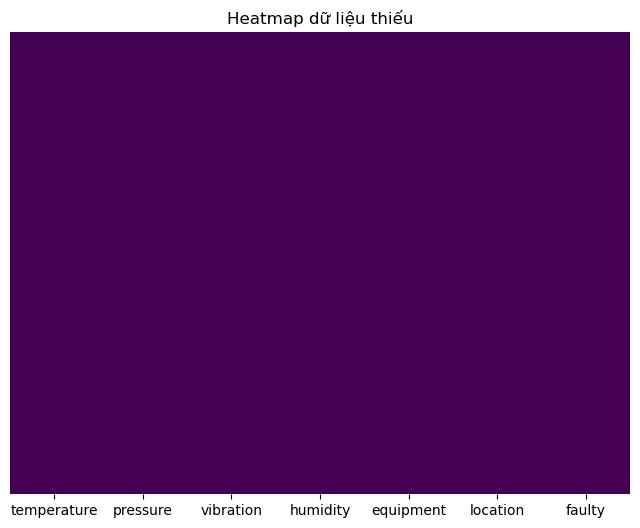

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Heatmap dữ liệu thiếu")
plt.show()

Biểu đồ phân phối

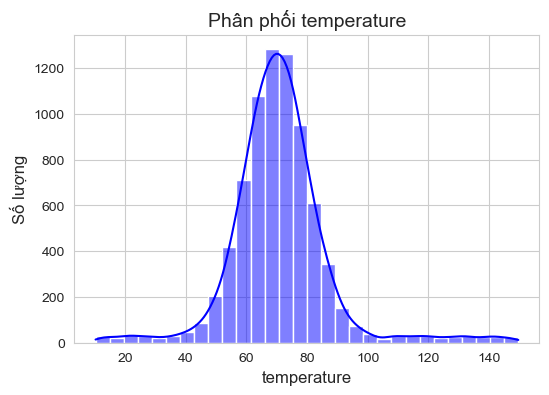

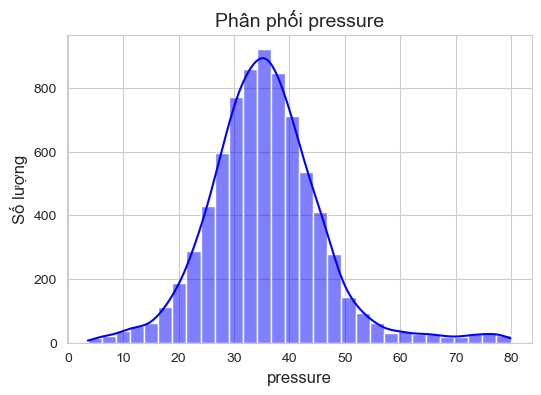

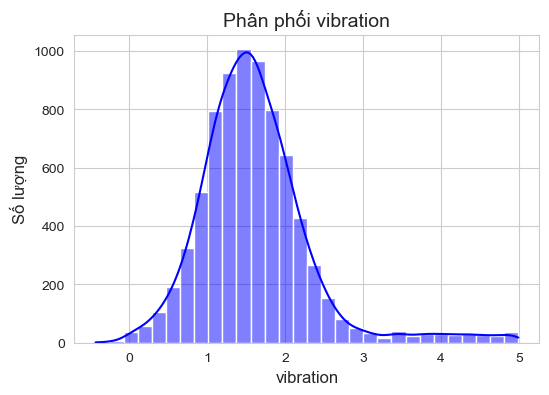

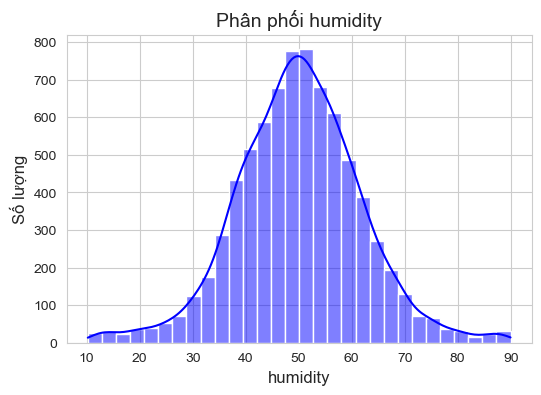

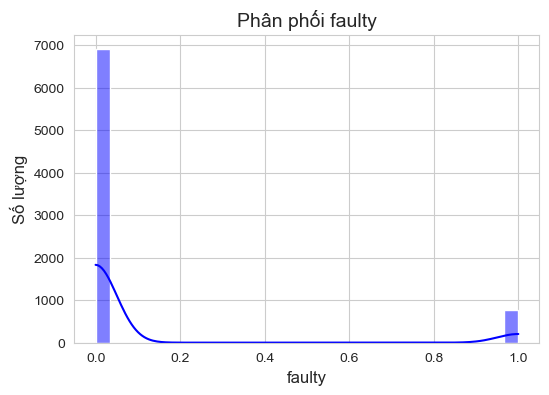

In [10]:
sns.set_style('whitegrid')
for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6, 4))  
    sns.histplot(data=df, x=col, bins=30, kde=True, color='blue') 
    plt.title(f"Phân phối {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Số lượng", fontsize=12)
    plt.show()

Biểu đồ hộp

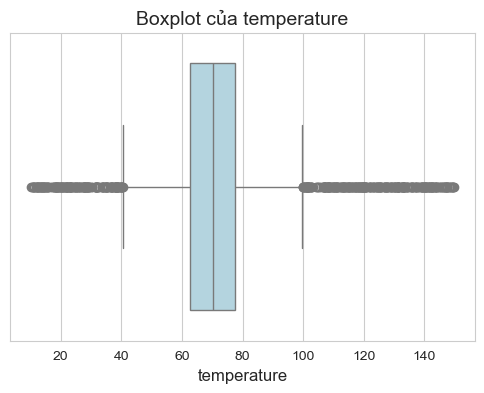

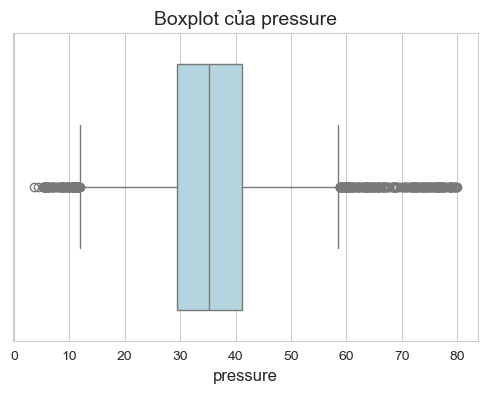

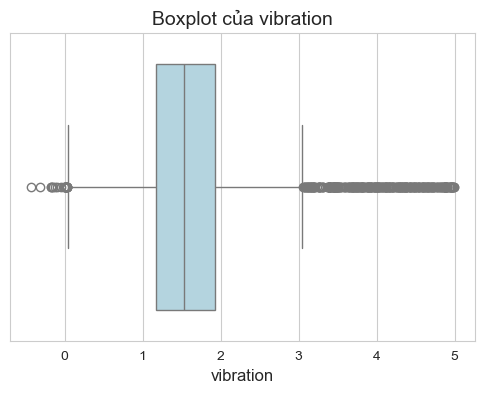

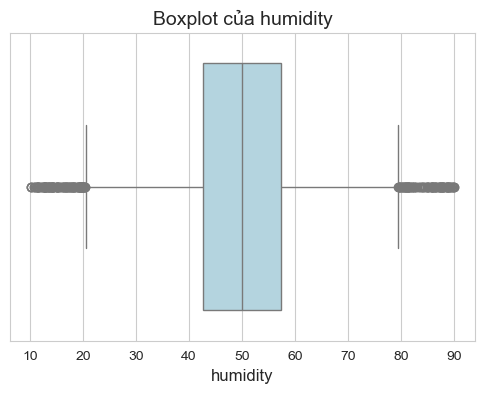

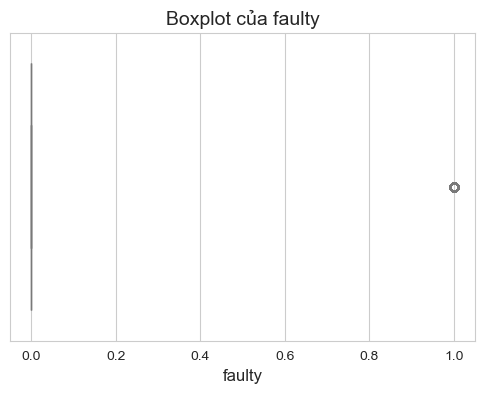

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, color='lightblue')  # Boxplot cho từng cột số
    plt.title(f"Boxplot của {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.show()


Biểu đồ đếm

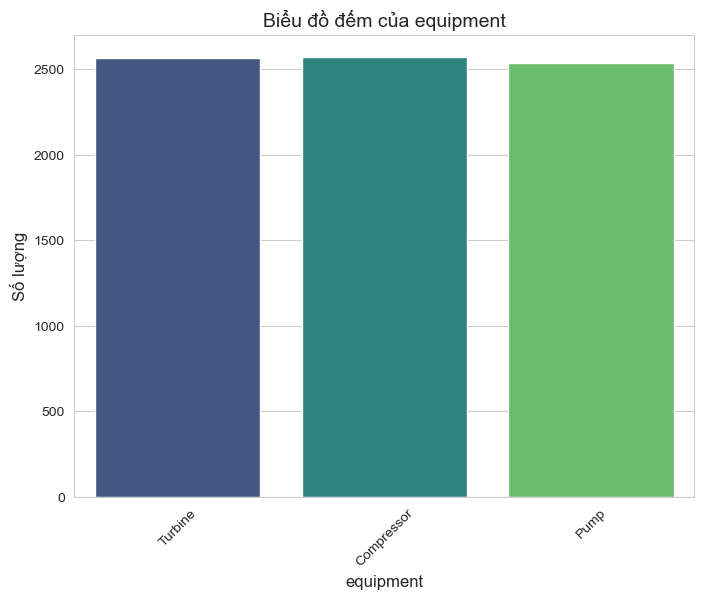

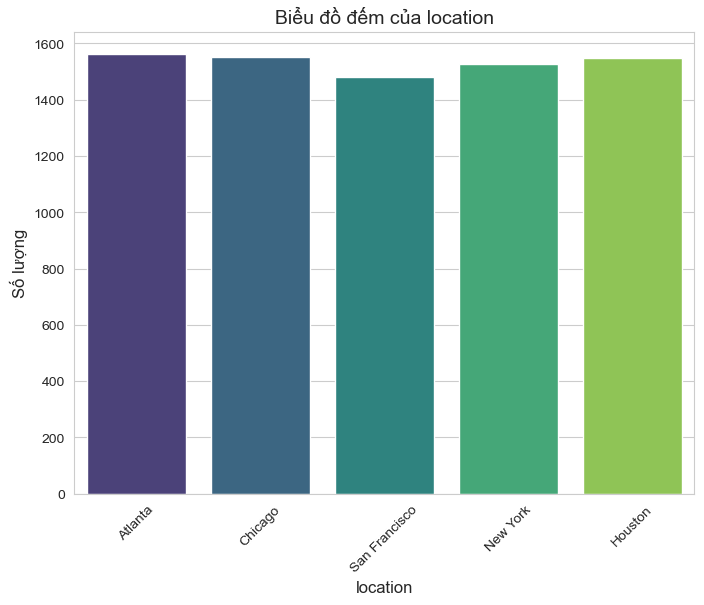

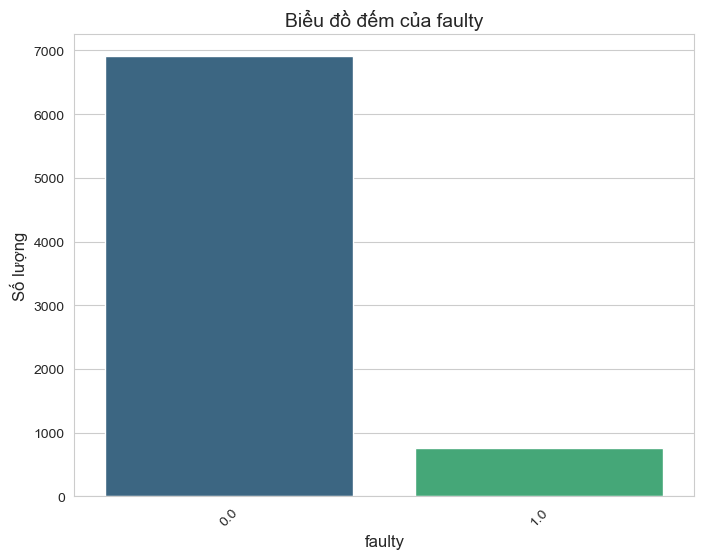

In [12]:
# Các cột phân loại trong dataset
categorical_columns = ['equipment', 'location', 'faulty']

sns.set_style('whitegrid')

for col in categorical_columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col, hue=col, palette="viridis", legend=False)
    plt.title(f"Biểu đồ đếm của {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Số lượng", fontsize=12)
    plt.xticks(rotation=45)
    plt.show()


Ma trận tương quan của các biến số

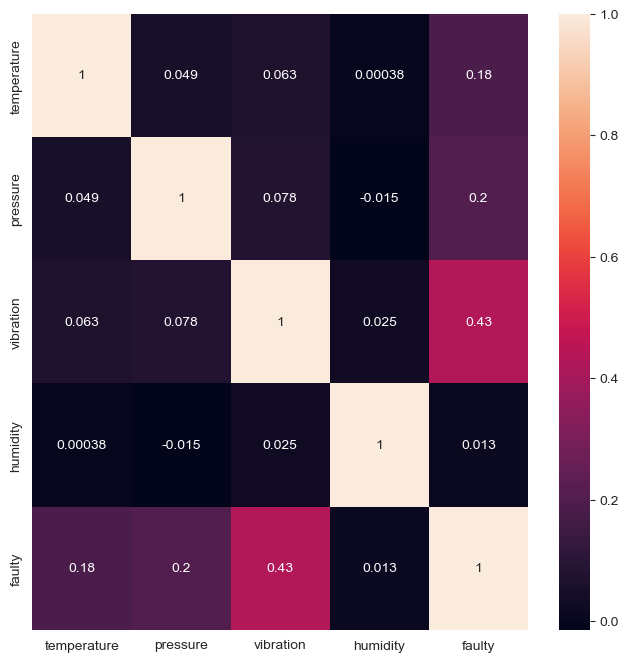

In [13]:
plt.figure(figsize=(8,8))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)
plt.show()

# Chuẩn bị dữ liệu

**Mã hoá cột phân loại** (`equipment`, `location`) bằng **Label Encoding**.  
**Tách đặc trưng (X)** và **nhãn (y)** với nhãn mục tiêu là `faulty`.  
**Chuẩn hoá dữ liệu số** bằng **StandardScaler** để đưa các đặc trưng về cùng thang đo.  
**Chia dữ liệu** thành tập huấn luyện và kiểm thử theo tỷ lệ 80/20, có **stratify** để giữ cân bằng nhãn.  


In [14]:
# Encode từng cột phân loại bằng encoder riêng
enc_equipment = LabelEncoder()
enc_location = LabelEncoder()

df['equipment'] = enc_equipment.fit_transform(df['equipment'])
df['location'] = enc_location.fit_transform(df['location'])

print("Dữ liệu sau khi mã hoá:")
print(df.head())

# Features & target
X = df.drop("faulty", axis=1)
y = df["faulty"]

# Chia train/test trước khi chuẩn hoá 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Chuẩn hoá features số
scaler = StandardScaler()

# Fit scaler trên train, rồi transform cả train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nKích thước tập train/test:")
print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)

Dữ liệu sau khi mã hoá:
   temperature   pressure  vibration   humidity  equipment  location  faulty
0    58.180180  25.029278   0.606516  45.694907          2         0     0.0
1    75.740712  22.954018   2.338095  41.867407          0         1     0.0
2    71.358594  27.276830   1.389198  58.954409          2         4     0.0
3    71.616985  32.242921   1.770690  40.565138          1         0     0.0
4    66.506832  45.197471   0.345398  43.253795          1         3     0.0

Kích thước tập train/test:
X_train: (6137, 6)
X_test : (1535, 6)


**Phân cụm bằng KMeans**:
- Áp dụng **KMeans** với `n_clusters=2` để chia dữ liệu thành 2 nhóm.  
- Chọn 2 đặc trưng chính: **temperature** và **pressure** để trực quan hoá kết quả phân cụm.  
- Kết quả được biểu diễn bằng biểu đồ scatter, mỗi cụm có màu khác nhau để dễ so sánh.  


In [15]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

feature_x = 'temperature'
feature_y = 'pressure'

fig7 = px.scatter(
    X, 
    x=feature_x, 
    y=feature_y, 
    color=clusters.astype(str),  
    title=f"KMeans Clustering ({feature_x} vs {feature_y})",
    labels={feature_x: feature_x.capitalize(), feature_y: feature_y.capitalize()}
)

fig7.show()   


**Phát hiện bất thường bằng Isolation Forest**:
- Sử dụng **Isolation Forest** với tỷ lệ bất thường `contamination=0.1` để phát hiện điểm dữ liệu bất thường.  
- Thêm cột `anomaly` vào dataset để đánh dấu các điểm bình thường và bất thường.  
- Trực quan hóa bằng biểu đồ scatter theo hai đặc trưng **temperature** và **pressure**, trong đó màu sắc thể hiện sự khác biệt giữa dữ liệu bình thường và bất thường.  


In [16]:
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df["anomaly"] = iso_forest.fit_predict(X)

fig8 = px.scatter(
    df, 
    x="temperature", 
    y="pressure", 
    color="anomaly", 
    title="Anomaly Detection"
)

fig8.show()

# **Modeling**

## **Random Forest**

Thực hiện **tối ưu mô hình Random Forest** bằng **GridSearchCV** như sau:

- **Bước 1:** Xây dựng lưới tham số (`param_grid`) chứa các giá trị cần thử cho từng siêu tham số của Random Forest như:  
  - `n_estimators`: số lượng cây trong rừng.  
  - `max_depth`: giới hạn độ sâu tối đa của cây.  
  - `min_samples_split` và `min_samples_leaf`: kiểm soát kích thước node để tránh overfitting.  
  - `max_features`: số đặc trưng được chọn khi chia node.  

- **Bước 2:** Khởi tạo mô hình Random Forest với `class_weight="balanced"` để xử lý mất cân bằng dữ liệu.  

- **Bước 3:** Sử dụng `GridSearchCV` để thử tất cả các tổ hợp tham số, đánh giá bằng **F1-score**, dùng **5-fold cross-validation**, và chạy song song để tăng tốc (`n_jobs=-1`).  

- **Bước 4:** Huấn luyện (`fit`) trên tập train đã chuẩn hoá để tìm bộ tham số tốt nhất, sau đó in ra **tham số tối ưu** và **điểm F1 trung bình cao nhất**.  

- **Bước 5:** Lấy mô hình tối ưu (`best_estimator_`) và dùng nó để **dự đoán trên tập test**, phục vụ bước đánh giá cuối cùng.
```


In [17]:
# Định nghĩa lưới tham số
param_grid = {
    'n_estimators': [100, 200, 300],            # số lượng cây
    'max_depth': [None, 10, 20, 30],            # độ sâu tối đa
    'min_samples_split': [2, 5, 10],            # số mẫu tối thiểu để chia
    'min_samples_leaf': [1, 2, 4],              # số mẫu tối thiểu ở node lá
    'max_features': ['sqrt', 'log2'],           # số đặc trưng được xét ở mỗi split
}

# Khởi tạo mô hình 
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# Dùng GridSearchCV để tìm tham số tối ưu
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',            
    cv=5,                      # 5-fold cross-validation
    n_jobs=-1,                 # chạy song song cho nhanh
    verbose=2                  # hiện log quá trình
)

# Huấn luyện tìm tham số tốt nhất
grid_search.fit(X_train_scaled, y_train)

# In kết quả tốt nhất
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# Dùng mô hình tốt nhất để dự đoán
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_scaled)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Score: 0.908120781738431


**Đánh giá mô hình Random Forest**:
- **Accuracy**: Độ chính xác của mô hình được tính bằng tỷ lệ dự đoán đúng trên tổng số mẫu kiểm tra.  
- **Classification Report**: Bao gồm các chỉ số quan trọng như Precision, Recall, F1-score cho từng lớp (Normal, Faulty).  
- **Confusion Matrix**: Ma trận nhầm lẫn thể hiện số lượng dự đoán đúng và sai của mô hình, giúp phân tích rõ ràng hơn hiệu suất dự đoán.  
- Trực quan hóa Confusion Matrix bằng heatmap để dễ dàng quan sát.  


Accuracy: 0.9837133550488599

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      1382
         1.0       0.96      0.88      0.91       153

    accuracy                           0.98      1535
   macro avg       0.97      0.94      0.95      1535
weighted avg       0.98      0.98      0.98      1535



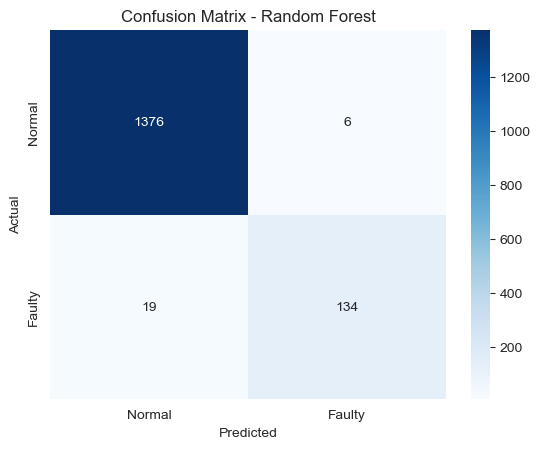

In [18]:
#Evaluation
acc_rf = accuracy_score(y_test, y_pred)
prec_rf = precision_score(y_test, y_pred)
rec_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Faulty"],
            yticklabels=["Normal", "Faulty"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Phân tích tầm quan trọng của đặc trưng (Feature Importance)**:

- Mô hình **Random Forest** cho phép xác định mức độ quan trọng của từng đặc trưng trong việc phân loại.  
- Kết quả được sắp xếp theo độ quan trọng giảm dần, cho thấy các đặc trưng nào ảnh hưởng mạnh nhất đến việc dự đoán hệ thống **Normal** hay **Faulty**.  
- Biểu đồ cột trực quan hóa mức độ quan trọng giúp dễ dàng so sánh giữa các đặc trưng.  



Feature Importance - Random Forest
       Feature  Importance
0  temperature    0.330218
2    vibration    0.298011
1     pressure    0.211425
3     humidity    0.140753
5     location    0.012581
4    equipment    0.007012


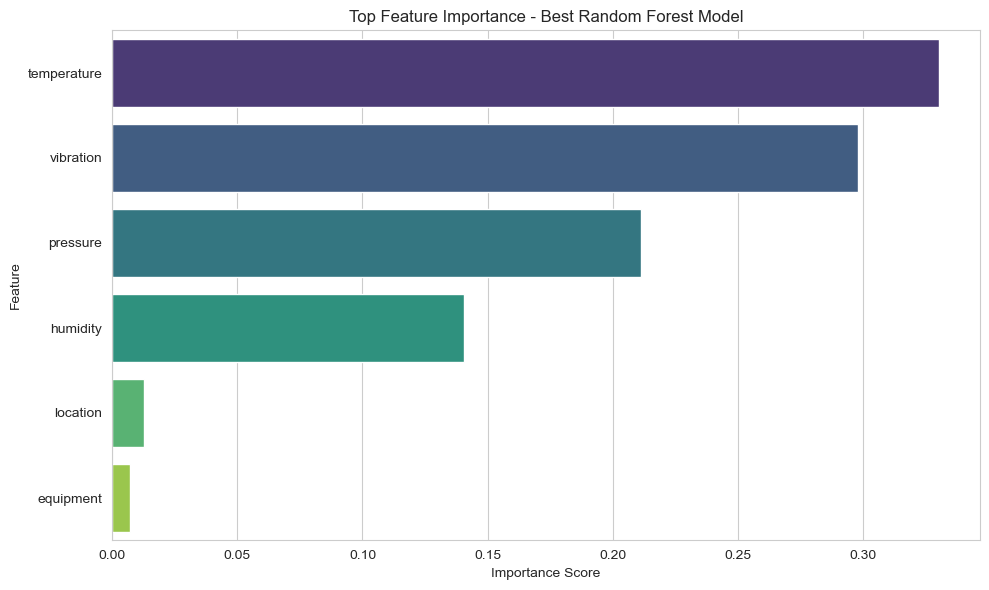

In [19]:
# Feature Importance 
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance - Random Forest")
print(feature_importance)

# Biểu đồ trực quan 
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",        
    dodge=False,
    legend=False,
    palette="viridis"
)
plt.title("Top Feature Importance - Best Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



## **Naive Bayes**

In [20]:
# Tạo mô hình Naive Bayes
nb_model = GaussianNB()

# Huấn luyện
nb_model.fit(X_train_scaled, y_train)


GaussianNB()

**Đánh giá mô hình Naive Bayes**:

- Sử dụng tập **test set** để dự đoán nhãn với mô hình **Naive Bayes**.  
- Độ chính xác (**Accuracy**) và **Classification Report** (Precision, Recall, F1-score) được in ra để đánh giá hiệu suất mô hình.  
- Báo cáo này giúp so sánh giữa các lớp (**Normal** và **Faulty**) và xem mô hình cân bằng ra sao trong việc phân loại.  


In [21]:
# Dự đoán
y_pred = nb_model.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred)
prec_nb = precision_score(y_test, y_pred)
rec_nb = recall_score(y_test, y_pred)
f1_nb = f1_score(y_test, y_pred)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9882736156351791

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      1382
         1.0       0.99      0.89      0.94       153

    accuracy                           0.99      1535
   macro avg       0.99      0.94      0.97      1535
weighted avg       0.99      0.99      0.99      1535



**Confusion Matrix - Naive Bayes**:

- Ma trận nhầm lẫn (Confusion Matrix) cho thấy số lượng mẫu được dự đoán đúng và sai của mô hình **Naive Bayes**.  
- Các ô chéo chính thể hiện số mẫu phân loại đúng (**True Positive**, **True Negative**), còn các ô ngoài chéo cho thấy các trường hợp phân loại nhầm (**False Positive**, **False Negative**).  
- Biểu đồ heatmap giúp trực quan hóa độ chính xác và lỗi của mô hình trong việc phân loại **Normal** và **Faulty**.  


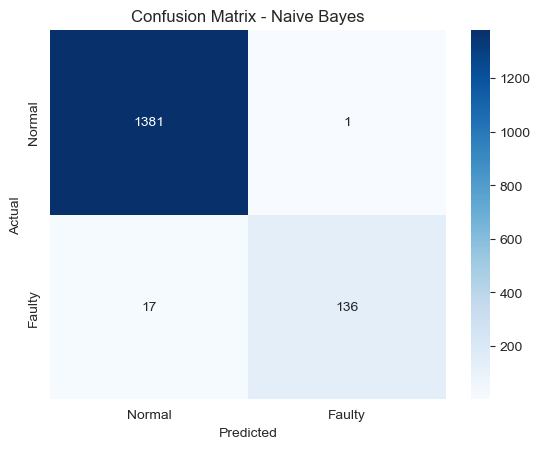

In [22]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Faulty"],
            yticklabels=["Normal", "Faulty"])
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **SVM**

In [23]:
# Tạo mô hình SVM với kernel RBF
svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)

# Huấn luyện
svm_model.fit(X_train_scaled, y_train)


SVC(class_weight='balanced', probability=True, random_state=42)

**Đánh giá mô hình SVM**:
- **Accuracy**: Tỉ lệ dự đoán đúng trên toàn bộ tập kiểm tra.  
- **Classification Report**: Hiển thị chi tiết precision, recall và F1-score cho từng lớp (**Normal**, **Faulty**).  
- Báo cáo này giúp đánh giá cân bằng giữa khả năng phát hiện lỗi (Faulty) và giữ độ chính xác cho trạng thái bình thường (Normal).  


In [24]:
# Dự đoán
y_pred = svm_model.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred)
prec_svm = precision_score(y_test, y_pred)
rec_svm = recall_score(y_test, y_pred)
f1_svm = f1_score(y_test, y_pred)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9726384364820847

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      1382
         1.0       0.84      0.90      0.87       153

    accuracy                           0.97      1535
   macro avg       0.91      0.94      0.93      1535
weighted avg       0.97      0.97      0.97      1535



**Confusion Matrix - SVM**:
- Biểu đồ hiển thị số lượng mẫu được phân loại đúng và sai giữa hai lớp **Normal** và **Faulty**.  
- Trục **Actual**: giá trị thực tế.  
- Trục **Predicted**: giá trị mô hình dự đoán.  
- Giúp đánh giá trực quan khả năng phát hiện lỗi (Faulty) và duy trì phân loại chính xác cho trạng thái bình thường (Normal).  


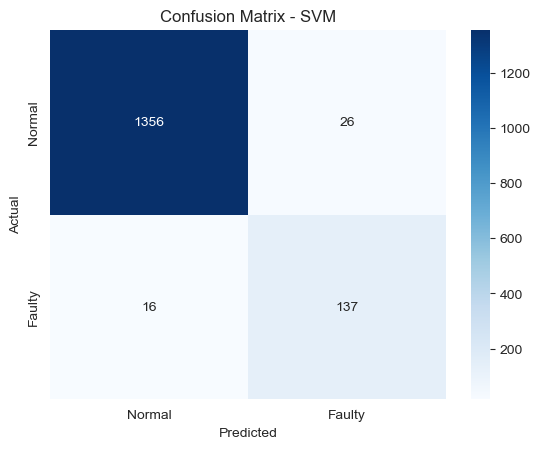

In [25]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Faulty"],
            yticklabels=["Normal", "Faulty"])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **ANN (MLP)**

- **Input layer**: số chiều đầu vào bằng số đặc trưng sau tiền xử lý.  
- **Hidden layers**: 
  - 1 lớp Dense 32 neurons (ReLU)  
  - 1 lớp Dense 16 neurons (ReLU)  
- **Output layer**: 1 neuron với hàm sigmoid cho bài toán phân loại nhị phân.  
- **Optimizer**: Adam  
- **Loss function**: Binary Crossentropy  
- **Metric**: Accuracy  
- Mô hình được huấn luyện với:
  - **Epochs**: 50  
  - **Batch size**: 16  
  - **Validation split**: 20% dữ liệu huấn luyện để đánh giá trong quá trình train.  


In [26]:
# Xây dựng mô hình ANN (MLP)
ann_model = Sequential()

# Input layer
ann_model.add(Input(shape=(X_train.shape[1],)))

# Hidden layers
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dense(16, activation='relu'))

# Output layer (1 neuron cho phân loại nhị phân)
ann_model.add(Dense(1, activation='sigmoid'))

# Compile mô hình
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Huấn luyện mô hình
history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8084 - loss: 0.5094 - val_accuracy: 0.9365 - val_loss: 0.2413
Epoch 2/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9525 - loss: 0.2012 - val_accuracy: 0.9650 - val_loss: 0.1298
Epoch 3/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9670 - loss: 0.1158 - val_accuracy: 0.9796 - val_loss: 0.0829
Epoch 4/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9797 - loss: 0.0828 - val_accuracy: 0.9813 - val_loss: 0.0663
Epoch 5/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9807 - loss: 0.0704 - val_accuracy: 0.9813 - val_loss: 0.0605
Epoch 6/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9824 - loss: 0.0633 - val_accuracy: 0.9829 - val_loss: 0.0569
Epoch 7/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.0590 - val_accuracy: 0.9845 - val_loss: 0.0517
Epoch 8/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9863 - loss: 0.0512 - val_accuracy: 0.

**Đánh giá mô hình ANN (MLP)**:

- **Accuracy**: đo độ chính xác tổng thể trên tập test.  
- **Classification Report**: hiển thị Precision, Recall, F1-score cho từng lớp (Normal, Faulty).  
- **Confusion Matrix**: trực quan hóa kết quả dự đoán so với nhãn thật.  

Kết quả:
- Accuracy cho biết tỉ lệ dự đoán đúng.  
- Classification report giúp phân tích chi tiết mô hình dự đoán tốt/thấp cho từng lớp.  
- Confusion matrix hỗ trợ nhận diện loại lỗi mà mô hình hay dự đoán sai.  


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.9811074918566776

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      1382
         1.0       0.95      0.86      0.90       153

    accuracy                           0.98      1535
   macro avg       0.97      0.93      0.94      1535
weighted avg       0.98      0.98      0.98      1535



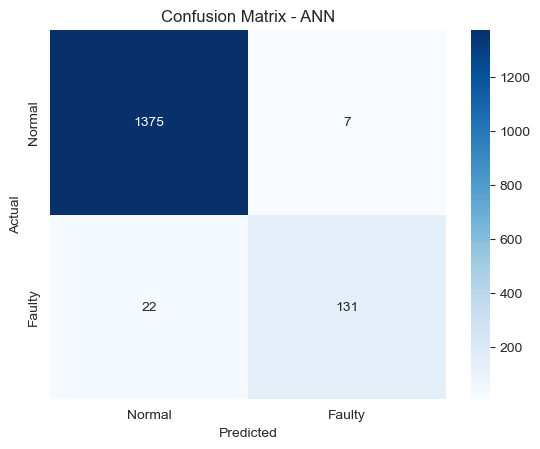

In [27]:
# Dự đoán trên tập test
y_pred_prob = ann_model.predict(X_test_scaled) # xác suất sigmoid
y_pred = (y_pred_prob > 0.5).astype(int)       # chuyển thành 0/1

acc_ann = accuracy_score(y_test, y_pred)
prec_ann = precision_score(y_test, y_pred)
rec_ann = recall_score(y_test, y_pred)
f1_ann = f1_score(y_test, y_pred)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Faulty"],
    yticklabels=["Normal", "Faulty"]
)
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Biểu đồ Accuracy qua các Epochs**:

Biểu đồ thể hiện sự thay đổi của **độ chính xác (Accuracy)** trong quá trình huấn luyện:

- **Training Accuracy**: độ chính xác trên tập huấn luyện.  
- **Validation Accuracy**: độ chính xác trên tập validation.  

Mục đích:  
- Quan sát quá trình học của mô hình.  
- Phát hiện tình trạng **overfitting** (khi training accuracy tăng cao nhưng validation accuracy không tăng hoặc giảm).  
- Đánh giá tính ổn định của mô hình qua số epoch.


In [28]:
# Vẽ biểu đồ Accuracy theo epochs
fig10 = go.Figure()
fig10.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig10.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))

fig10.update_layout(
    title="Model Accuracy Over Epochs - ANN",
    xaxis_title="Epochs",
    yaxis_title="Accuracy"
)

fig10.show()


## **LSTM**
- **Reshape dữ liệu đầu vào**: Chuyển `X_train` và `X_test` từ dạng 2D `(samples, features)` sang dạng 3D `(samples, timesteps, features)` để phù hợp với kiến trúc LSTM. Ở đây `timesteps = 1` vì dữ liệu không có chuỗi thời gian.  

- **One-hot encode target**: Chuyển nhãn `y_train` và `y_test` thành dạng one-hot vector để huấn luyện mô hình phân loại nhiều lớp (Normal/Faulty).  


In [29]:
# Chuyển dữ liệu sang dạng NumPy và reshape cho LSTM: (samples, timesteps=1, features)
X_train_lstm = np.array(X_train_scaled).reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm  = np.array(X_test_scaled).reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

Xây dựng và huấn luyện mô hình LSTM


In [30]:
# Xây dựng mô hình LSTM
model = Sequential([
    Input(shape=(1, X_train_lstm.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')   # sigmoid cho binary classification
])

# Compile
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Huấn luyện
history = model.fit(
    X_train_lstm, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8601 - loss: 0.4766 - val_accuracy: 0.9511 - val_loss: 0.1549
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9642 - loss: 0.1247 - val_accuracy: 0.9731 - val_loss: 0.0815
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0806 - val_accuracy: 0.9821 - val_loss: 0.0591
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.0702 - val_accuracy: 0.9845 - val_loss: 0.0525
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9812 - loss: 0.0650 - val_accuracy: 0.9853 - val_loss: 0.0510
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9865 - loss: 0.0572 - val_accuracy: 0.9837 - val_loss: 0.0492
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.0504 - val_accuracy: 0.9845 - val_loss: 0.0508
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9807 - loss: 0.0629 - val_accuracy: 0.

**Đánh giá mô hình LSTM**:
- **Dự đoán**: Sử dụng mô hình đã huấn luyện để dự đoán nhãn trên tập kiểm thử.  
- **Accuracy**: Tính độ chính xác của mô hình trên dữ liệu test.  
- **Classification Report**: Hiển thị precision, recall, f1-score cho từng lớp (Normal/Faulty).  
- **Confusion Matrix**: Minh họa trực quan số lượng mẫu được phân loại đúng/sai giữa hai lớp.  


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.9804560260586319

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      1382
         1.0       0.98      0.82      0.89       153

    accuracy                           0.98      1535
   macro avg       0.98      0.91      0.94      1535
weighted avg       0.98      0.98      0.98      1535



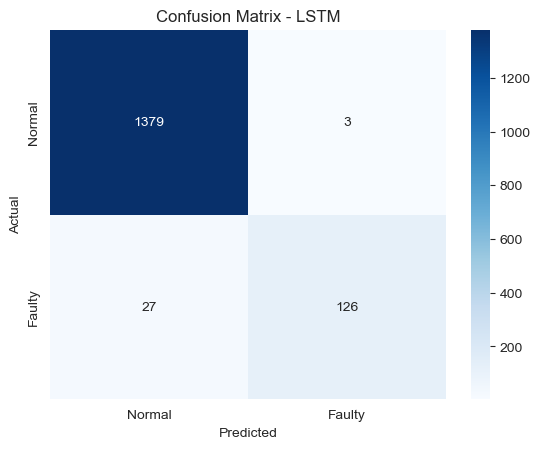

In [31]:
# Dự đoán
y_pred_prob = model.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

acc_lstm = accuracy_score(y_test, y_pred)
prec_lstm = precision_score(y_test, y_pred)
rec_lstm = recall_score(y_test, y_pred)
f1_lstm = f1_score(y_test, y_pred)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Faulty"],
            yticklabels=["Normal", "Faulty"])
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Biểu đồ Accuracy qua các Epochs**:

Biểu đồ thể hiện sự thay đổi của **độ chính xác (Accuracy)** trong quá trình huấn luyện:

- **Training Accuracy**: độ chính xác trên tập huấn luyện.  
- **Validation Accuracy**: độ chính xác trên tập validation.  

Mục đích:  
- Quan sát quá trình học của mô hình.  
- Phát hiện tình trạng **overfitting** (khi training accuracy tăng cao nhưng validation accuracy không tăng hoặc giảm).  
- Đánh giá tính ổn định của mô hình qua số epoch.


In [32]:
# Vẽ biểu đồ Accuracy theo epochs 
import plotly.graph_objects as go

fig10 = go.Figure()
fig10.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig10.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))

fig10.update_layout(
    title="Model Accuracy Over Epochs - LSTM",
    xaxis_title="Epochs",
    yaxis_title="Accuracy"
)

fig10.show()


# So sánh kết quả các mô hình

Sau khi huấn luyện và đánh giá 5 mô hình (**Random Forest, Naive Bayes, SVM, ANN, LSTM**), ta tổng hợp các chỉ số **Accuracy, Precision, Recall, F1-Score** vào bảng và biểu đồ dưới đây để so sánh trực quan:

- **Bảng kết quả**: hiển thị các chỉ số đánh giá của từng mô hình.  
- **Biểu đồ cột**: minh họa sự khác biệt về hiệu suất giữa các mô hình.  

Điều này giúp dễ dàng lựa chọn mô hình tối ưu cho bài toán phân loại lỗi thiết bị.


           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.983713   0.957143  0.875817  0.914676
1    Naive Bayes  0.988274   0.992701  0.888889  0.937931
2            SVM  0.972638   0.840491  0.895425  0.867089
3            ANN  0.981107   0.949275  0.856209  0.900344
4           LSTM  0.980456   0.976744  0.823529  0.893617


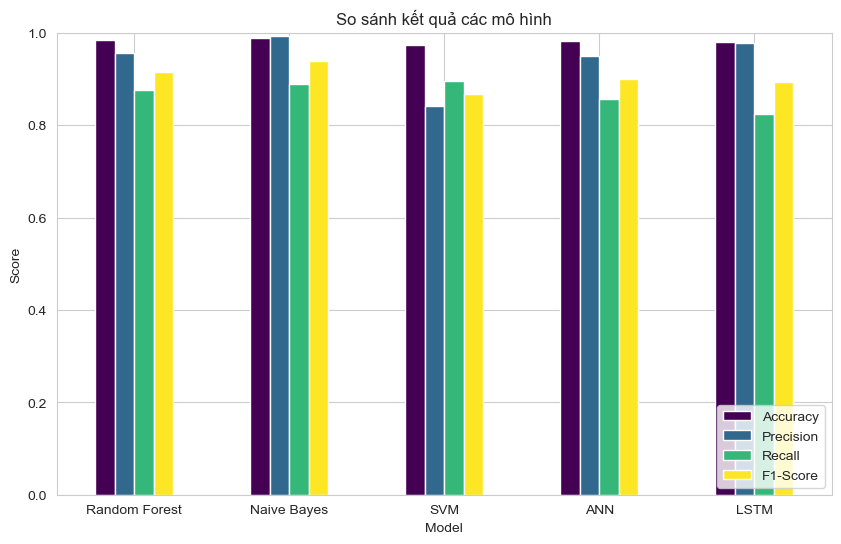

In [33]:
# Tạo bảng kết quả
results = pd.DataFrame({
    "Model": ["Random Forest", "Naive Bayes", "SVM", "ANN", "LSTM"],
    "Accuracy": [acc_rf, acc_nb, acc_svm, acc_ann, acc_lstm],
    "Precision": [prec_rf, prec_nb, prec_svm, prec_ann, prec_lstm],
    "Recall": [rec_rf, rec_nb, rec_svm, rec_ann, rec_lstm],
    "F1-Score": [f1_rf, f1_nb, f1_svm, f1_ann, f1_lstm]
})

print(results)

# Vẽ biểu đồ so sánh
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", figsize=(10,6), colormap="viridis", rot=0
)

plt.title("So sánh kết quả các mô hình")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()
